# 1. Data loading

### 1.1 Importing modules

In [19]:
# import all modules
import pandas as pd
import geopandas as gpd
import requests

In [20]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/2'

response=requests.get(area_url)
# print(response.text) #here I saw that its already plain text and not json to parse, no .json() to unpack required

#Check
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,55.54527,44.22956,298.35,0.50,0.66,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.59,0.58,N
1,56.10518,41.52589,300.58,0.39,0.59,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.38,0.37,N
2,56.13894,44.11552,304.68,0.47,0.64,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.54,1.16,N
3,56.14229,44.12248,298.69,0.47,0.64,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.87,0.81,N
4,59.50502,32.09431,316.92,0.47,0.40,2026-05-10,45,N20,VIIRS,n,2.0NRT,271.38,2.11,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36718,40.64381,-89.64011,303.72,0.60,0.70,2026-05-11,859,N20,VIIRS,n,2.1URT,278.77,1.12,N
36719,41.17947,-87.85845,309.24,0.70,0.70,2026-05-11,859,N20,VIIRS,n,2.1URT,278.95,1.98,N
36720,41.18346,-87.85751,308.40,0.70,0.70,2026-05-11,859,N20,VIIRS,n,2.1URT,278.24,1.90,N
36721,41.41431,-88.18508,296.89,0.60,0.70,2026-05-11,859,N20,VIIRS,n,2.1URT,281.05,1.60,N


# 2. Data cleaning

In [3]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
wildfire_gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,55.54527,44.22956,298.35,0.50,0.66,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.59,0.58,N,POINT (44.22956 55.54527)
1,56.10518,41.52589,300.58,0.39,0.59,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.38,0.37,N,POINT (41.52589 56.10518)
2,56.13894,44.11552,304.68,0.47,0.64,2026-05-10,45,N20,VIIRS,n,2.0NRT,273.54,1.16,N,POINT (44.11552 56.13894)


# 3. Spatial analysis

In [4]:
#Classify wildfire strength
wildfire_gdf["frp"].head(3)
wildfire_gdf["frp"].describe()

high_intensity= wildfire_gdf["frp"] > 400
medium_intensity= (wildfire_gdf["frp"] <= 400) &  (wildfire_gdf["frp"] > 200) #instead of and, because pandas different combination
low_intensity=wildfire_gdf["frp"] <= 200


In [6]:
# Read in for background map with sha
land = gpd.read_file("../data/raw/ne_10m_land.zip").to_crs(epsg=4326) # eine Ebene höher gehen, um von notebook raus und bei data folder rein
ocean = gpd.read_file("../data/raw/ne_10m_ocean.zip").to_crs(epsg=4326)

<Axes: >

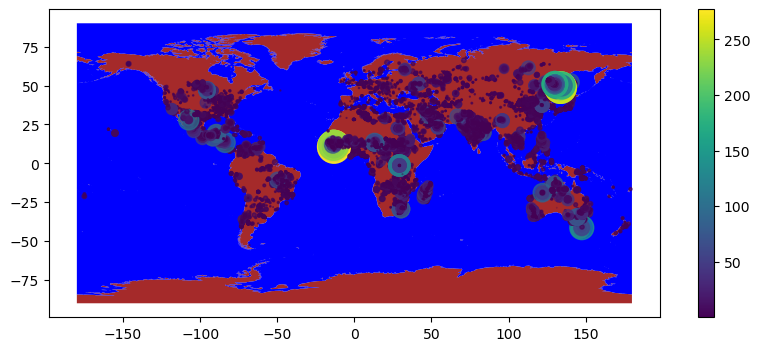

In [7]:
import matplotlib.pyplot as plt

fig, ax= plt.subplots(figsize=(10,4))

land.plot(ax=ax, color="brown")
ocean.plot(ax=ax, color="blue")

size=wildfire_gdf["frp"]/2
wildfire_gdf.plot(ax=ax, column=size, markersize="frp", alpha=0.7, legend=True)

In [8]:
!pip install contextily
import contextily as cx

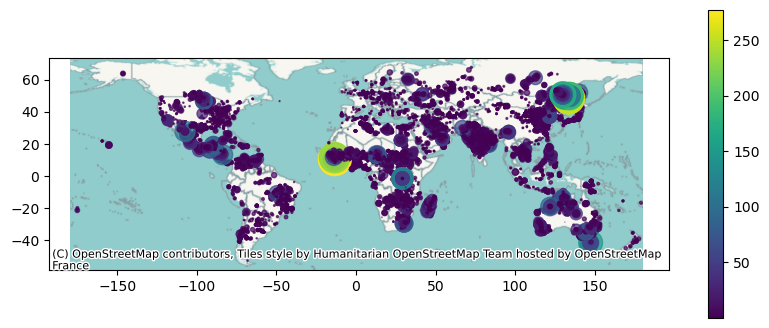

In [10]:
import contextily as cx

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column=size, markersize="frp", alpha=0.7, legend=True)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


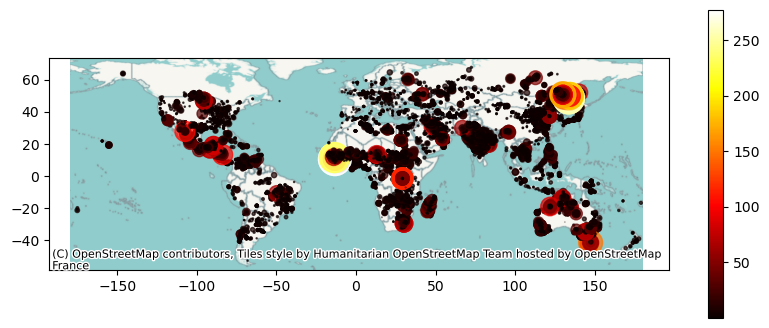

In [ ]:
#Without normalization
import contextily as cx

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column=size, cmap="hot", markersize="frp", alpha=0.7, legend=True)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


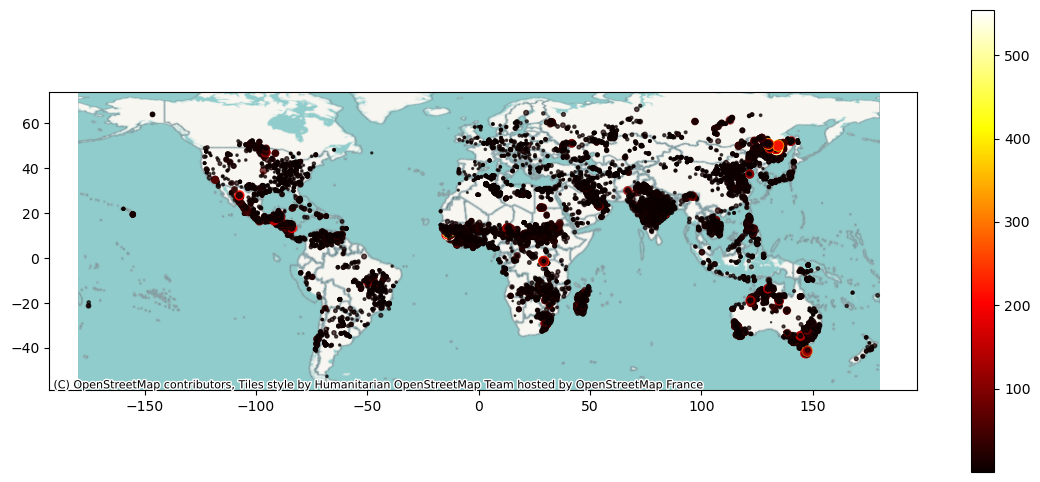

In [ ]:
# With normalization

import numpy as np

sizes = np.sqrt(wildfire_gdf["frp"]) * 3

fig, ax = plt.subplots(figsize=(14,6))

wildfire_gdf.plot(
    ax=ax,
    column="frp",
    cmap="hot",
    markersize=sizes,
    alpha=0.7,
    legend=True
)

cx.add_basemap(ax=ax, crs=4326)

plt.show()

In [ ]:
# Next step: Do proper map, with normalizing, making classification, handling missing values and so on using this code and practicals VL8
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cmcrameri.cm as cmc
# import numpy as np

# # Load the data
# nuts = gpd.read_file("data/nuts_rg_03m_2024_3035_pop_wm_eu.gpkg")

# # Calculate the offset to center the diverging map at 100
# # We find the furthest distance from 100 to make the scale symmetrical
# data_min = nuts['women_per100men'].quantile(0.01)
# data_max = nuts['women_per100men'].quantile(0.99)
# diff = max(abs(data_min - 100), abs(data_max - 100))

# vmin = 100 - diff
# vmax = 100 + diff

# # 1. Setup
# fig, ax = plt.subplots(figsize=(12, 10))

# # 4. Legend options
# legend_options = {
#     "label": "Ratio: Women per 100 Men",
#     "orientation": "vertical",
#     "shrink": 0.7
# }

# # 6. Missing data options
# missing_styling = {
#     "color": "#EEEEEE",
#     "label": "No Data"
# }

# # 2, 3, 5. Plot the choropleth
# nuts.plot(
#     ax=ax,
#     column="women_per100men",
#     cmap=cmc.vik, 
#     vmin=vmin,
#     vmax=vmax,
#     legend=True,
#     legend_kwds=legend_options,
#     missing_kwds=missing_styling,
#     edgecolor="black",
#     linewidth=0.1
# )

# # 7. Formatting
# ax.set_title("Gender Ratio Across European Regions", fontsize=16)
# ax.axis("off")

# plt.show()

In [ ]:
#Backup, but folium unstable 
# import folium
# from folium.plugins import MarkerCluster

# # Create a new Folium map object.
# background_map = folium.Map()
# folium.GeoJson(wildfire_gdf).add_to(background_map) 
# background_map

# 4. Visualization

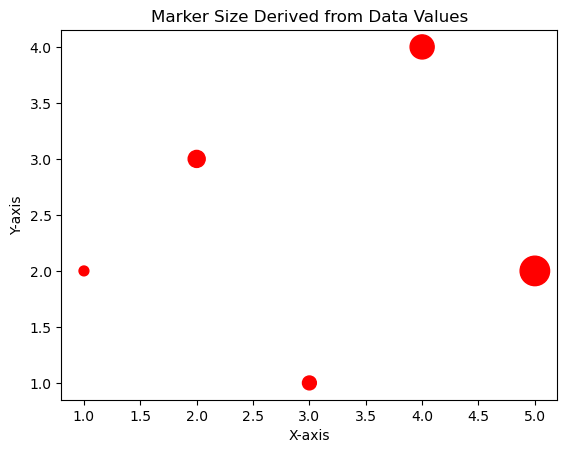

In [ ]:
# Inspirational

# import matplotlib.pyplot as plt
# import numpy as np

# x = np.array([1, 2, 3, 4, 5])
# y = np.array([2, 3, 1, 4, 2])
# data_value = np.array([100, 300, 200, 600, 900])  # data features
# sizes = data_value / 2  # Scale them down

# plt.scatter(x, y, s=sizes, c='red')
# plt.title("Marker Size Derived from Data Values")
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.show()